# Big Data Analytics

Group 13

- Beatris Daicu, 20221854
- Diogo Carvalho, 2022
- Ricardo Pereira, 2025
- Yehor Malakhov, 2022

The goal in this notebook is to predict whether a NYC Yellow Taxi trip results
in a high tip, that is defined as at least 20% of the pre-tip fare, using the
January 2026 TLC dataset. The binary label `high_tip` is calculated from
`tip_amount / (total_amount − tip_amount)`, and a secondary regression task runs
in parallel to predict the exact `tip_percentage`.


## 1. Import Libraries and Spark Initialization


In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml import Pipeline
from pyspark.ml.classification import (
    GBTClassifier,
    LogisticRegression,
    RandomForestClassifier,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator,
    RegressionEvaluator,
)
from pyspark.ml.feature import (
    OneHotEncoder,
    StandardScaler,
    StringIndexer,
    VectorAssembler,
)
from pyspark.ml.regression import GBTRegressor, LinearRegression
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    avg,
    col,
    count,
    dayofweek,
    desc,
    hour,
    unix_timestamp,
    when,
)
from pyspark.sql.functions import round as spark_round

In [2]:
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-21-openjdk"

spark = (
    SparkSession.builder.appName("NYC_Yellow_Taxi_Analysis")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/02 19:41:39 WARN Utils: Your hostname, cachyos-desktop, resolves to a loopback address: 127.0.1.1; using 192.168.1.80 instead (on interface enp14s0)
26/06/02 19:41:39 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/02 19:41:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 2. Loading the Dataset


In [3]:
trips = spark.read.parquet("../data/yellow_tripdata_2026-01.parquet")

trips.printSchema()

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



In [4]:
print(f"Number of rows: {trips.count():,}")
print(f"Number of columns: {len(trips.columns)}")

Number of rows: 3,724,889
Number of columns: 20


In [5]:
trips.show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|Airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|2       |2026-01-01 00:54:04 |2026-01-01 00:59:37  |1              |0.97         |1         |N                 |239         |238 

Before any filtering, it is worth checking the payment type distribution as tips
only appear for credit card transactions (type 1), so this tells us upfront how
much of the raw data is actually usable.


In [6]:
trips.groupBy("payment_type").agg(count("*").alias("num_trips")).orderBy(
    desc("num_trips")
).show()

+------------+---------+
|payment_type|num_trips|
+------------+---------+
|           1|  2249747|
|           0|  1088058|
|           2|   314043|
|           4|    56400|
|           3|    16641|
+------------+---------+



## 3. Data Understanding


### 3.1 Filtering

Only credit card trips have tip amounts recorded, so filtering on
`payment_type == 1` comes first. The remaining conditions are basic sanity
checks like negative fares, zero-distance trips, and records where the tip
exceeds the total.


In [7]:
trips_rdd = trips.rdd

In [8]:
trips_rdd = (
    trips_rdd.filter(lambda row: row.payment_type == 1)
    .filter(lambda row: row.fare_amount > 0)
    .filter(lambda row: row.tip_amount >= 0)
    .filter(lambda row: row.total_amount > row.tip_amount)
    .filter(lambda row: row.trip_distance > 0)
    .filter(lambda row: row.passenger_count > 0)
    .filter(lambda row: row.tpep_pickup_datetime < row.tpep_dropoff_datetime)
)

trips_rdd.count()

2180791

In [9]:
trips_ml = trips_rdd.toDF()

### 3.2 Derived Columns

| Column                  | Formula                                        |
| ----------------------- | ---------------------------------------------- |
| `trip_duration_minutes` | (`dropoff` − `pickup`) / 60                    |
| `tip_percentage`        | `tip_amount` / (`total_amount` − `tip_amount`) |
| `high_tip` (label)      | 1 if `tip_percentage` ≥ 0.20, else 0           |


In [10]:
trips_ml = trips_ml.withColumn(
    "trip_duration_minutes",
    (
        unix_timestamp("tpep_dropoff_datetime")
        - unix_timestamp("tpep_pickup_datetime")
    )
    / 60,
)

trips_ml = trips_ml.withColumn(
    "tip_percentage",
    col("tip_amount") / (col("total_amount") - col("tip_amount")),
)

trips_ml = trips_ml.withColumn(
    "high_tip", when(col("tip_percentage") >= 0.20, 1).otherwise(0)
)

Apply the duration filter and inspect the class balance.


In [11]:
trips_ml = trips_ml.filter(
    (col("trip_duration_minutes") > 1) & (col("trip_duration_minutes") <= 180)
)

trips_ml.groupBy("high_tip").count().show()

+--------+-------+
|high_tip|  count|
+--------+-------+
|       1| 944773|
|       0|1229530|
+--------+-------+



## 4. Data Cleaning and Feature Engineering


### 4.1 Temporal Features


In [12]:
trips_ml = trips_ml.withColumn("pickup_hour", hour(col("tpep_pickup_datetime")))

trips_ml = trips_ml.withColumn(
    "pickup_dayofweek", dayofweek(col("tpep_pickup_datetime"))
)

Breaking the timestamp into hour and day-of-week lets the model pick up on
tipping patterns that vary by time, as late night trips or weekend travel likely
behave differently from weekday commutes.


### 4.2 Final Feature Set

Categorical features: `VendorID`, `RatecodeID`, `PULocationID`, `DOLocationID`,
`pickup_hour`, `pickup_dayofweek`

Numeric features: `passenger_count`, `trip_distance`, `fare_amount`, `extra`,
`mta_tax`, `tolls_amount`, `improvement_surcharge`, `congestion_surcharge`,
`Airport_fee`, `cbd_congestion_fee`, `trip_duration_minutes`


In [13]:
model_data = trips_ml.select(
    "VendorID",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "extra",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
    "trip_duration_minutes",
    "pickup_hour",
    "pickup_dayofweek",
    col("high_tip").cast("double").alias("label"),
)

## 5. Exploratory Data Analysis


### 5.1 Feature Column Lists


In [14]:
categorical_cols = [
    "VendorID",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "pickup_hour",
    "pickup_dayofweek",
]

numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
    "trip_duration_minutes",
]

### 5.2 Preprocessing Pipeline


In [15]:
indexers = [
    StringIndexer(
        inputCol=col_name, outputCol=col_name + "_index", handleInvalid="keep"
    )
    for col_name in categorical_cols
]

encoder = OneHotEncoder(
    inputCols=[col_name + "_index" for col_name in categorical_cols],
    outputCols=[col_name + "_encoded" for col_name in categorical_cols],
)

assembler = VectorAssembler(
    inputCols=numeric_cols
    + [col_name + "_encoded" for col_name in categorical_cols],
    outputCol="features_unscaled",
)

scaler = StandardScaler(
    inputCol="features_unscaled",
    outputCol="features",
    withStd=True,
    withMean=False,
)

### 5.3 Summary Statistics


In [16]:
print("Final number of rows for modelling:", model_data.count())
print("Number of columns:", len(model_data.columns))

Final number of rows for modelling: 2174303
Number of columns: 18


#### Class balance

Are high-tip trips under or over represented?


In [17]:
total_rows = model_data.count()

model_data.groupBy("label").agg(
    count("*").alias("num_trips"),
    spark_round((count("*") / total_rows) * 100, 2).alias("percentage"),
).orderBy("label").show()

+-----+---------+----------+
|label|num_trips|percentage|
+-----+---------+----------+
|  0.0|  1229530|     56.55|
|  1.0|   944773|     43.45|
+-----+---------+----------+



#### Descriptive statistics


In [18]:
model_data.select(
    "passenger_count", "trip_distance", "fare_amount", "trip_duration_minutes"
).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

26/06/02 19:42:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+------------------+-----------------+------------------+---------------------+
|summary|   passenger_count|    trip_distance|       fare_amount|trip_duration_minutes|
+-------+------------------+-----------------+------------------+---------------------+
|  count|           2174303|          2174303|           2174303|              2174303|
|   mean|1.2518968147493703|3.489786368321237|19.332475551936145|   17.147071245359932|
| stddev|0.6498200834388759| 67.3760469612413|17.647879147126474|   15.341816112536643|
|    min|                 1|             0.01|              0.01|   1.0166666666666666|
|    25%|                 1|              1.0|               9.3|    7.616666666666666|
|    50%|                 1|             1.69|              13.5|   12.533333333333333|
|    75%|                 1|              3.3|              21.9|                20.85|
|    max|                 8|         98773.58|             500.0|   179.96666666666667|
+-------+------------------+----

#### High-tip rate by hour of day

Are certain hours more generous?


In [19]:
model_data.groupBy("pickup_hour").agg(
    count("*").alias("num_trips"),
    spark_round(avg("label") * 100, 2).alias("high_tip_rate_pct"),
).orderBy(desc("high_tip_rate_pct")).show(24)

+-----------+---------+-----------------+
|pickup_hour|num_trips|high_tip_rate_pct|
+-----------+---------+-----------------+
|          2|    22131|            46.01|
|         21|   122103|             45.5|
|          1|    32555|            45.26|
|          3|    14756|            45.17|
|         22|   104365|            45.13|
|         13|   125154|            44.96|
|         11|   109797|            44.94|
|         12|   120687|            44.71|
|         14|   134881|            44.52|
|         20|   125186|            44.43|
|         15|   145375|            44.05|
|         10|   102248|            43.63|
|          0|    49990|            43.59|
|         18|   161377|            43.39|
|         23|    73816|            43.21|
|         19|   138450|            43.19|
|         17|   160203|            43.06|
|         16|   149392|            42.58|
|          9|    94487|            41.86|
|          4|     9963|            41.46|
|          8|    80623|           

#### High-tip rate by day of week

(1 = Sunday, 7 = Saturday).


In [20]:
model_data.groupBy("pickup_dayofweek").agg(
    count("*").alias("num_trips"),
    spark_round(avg("label") * 100, 2).alias("high_tip_rate_percentage"),
).orderBy("pickup_dayofweek").show()

+----------------+---------+------------------------+
|pickup_dayofweek|num_trips|high_tip_rate_percentage|
+----------------+---------+------------------------+
|               1|   194618|                   45.09|
|               2|   225638|                   42.69|
|               3|   297774|                   42.57|
|               4|   316739|                   42.82|
|               5|   388953|                   43.15|
|               6|   386761|                   42.63|
|               7|   363820|                   45.51|
+----------------+---------+------------------------+



#### High-tip rate by trip distance group


In [21]:
model_data_eda = model_data.withColumn(
    "distance_group",
    when(col("trip_distance") <= 2, "Short trip")
    .when(col("trip_distance") <= 6, "Medium trip")
    .otherwise("Long trip"),
)

model_data_eda.groupBy("distance_group").agg(
    count("*").alias("num_trips"),
    spark_round(avg("label") * 100, 2).alias("high_tip_rate_percentage"),
).orderBy("distance_group").show()

+--------------+---------+------------------------+
|distance_group|num_trips|high_tip_rate_percentage|
+--------------+---------+------------------------+
|     Long trip|   334091|                   20.57|
|   Medium trip|   572208|                   37.71|
|    Short trip|  1268004|                   52.07|
+--------------+---------+------------------------+



## 6 Train / Validation / Test Split and Caching

The dataset is split 70 / 15 / 15 with a fixed seed:

| Split        | Fraction | Purpose                                |
| ------------ | -------- | -------------------------------------- |
| `train_data` | 70 %     | Model fitting                          |
| `val_data`   | 15 %     | Hyperparameter tuning / early stopping |
| `test_data`  | 15 %     | Final evaluation only                  |

All three splits are cached to avoid recomputation during repeated evaluations.


In [22]:
train_data, temp_data = model_data.randomSplit([0.70, 0.30], seed=42)
val_data, test_data = temp_data.randomSplit([0.50, 0.50], seed=42)

print(f"Training rows: {train_data.count():,}")
print(f"Validation rows: {val_data.count():,}")
print(f"Test rows: {test_data.count():,}")

Training rows: 1,523,122


Validation rows: 326,477


Test rows: 324,704


In [23]:
train_data = train_data.cache()
val_data = val_data.cache()
test_data = test_data.cache()

### Evaluators

AUC-ROC is the primary metric since it measures discriminative ability across
all thresholds.

| Evaluator            | Metric           |
| -------------------- | ---------------- |
| `binary_evaluator`   | AUC-ROC          |
| `accuracy_evaluator` | Overall accuracy |
| `f1_evaluator`       | Macro F1         |


In [24]:
binary_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC",
)

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)

## 7. Model Training and Evaluation

Models are fitted on `train_data` and the results in this section use
`val_data`. Final scores are in Section 8.


### 7.1 Logistic Regression

It is the linear baseline, using the scaled `features` vector since gradient
descent convergence is sensitive to feature magnitudes.


In [25]:
lr = LogisticRegression(
    featuresCol="features", labelCol="label", maxIter=20, regParam=0.01
)

lr_pipeline = Pipeline(stages=[*indexers, encoder, assembler, scaler, lr])

lr_model = lr_pipeline.fit(train_data)

26/06/02 19:44:18 WARN MemoryStore: Not enough space to cache rdd_97_6 in memory! (computed 29.0 MiB so far)
26/06/02 19:44:18 WARN BlockManager: Persisting block rdd_97_6 to disk instead.


In [26]:
lr_predictions = lr_model.transform(val_data)

lr_predictions.select("label", "prediction", "probability").show(
    10, truncate=False
)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1.0  |1.0       |[0.42124290477679893,0.5787570952232011]|
|1.0  |0.0       |[0.508525043613712,0.491474956386288]   |
|1.0  |0.0       |[0.5059191682442311,0.4940808317557689] |
|0.0  |0.0       |[0.5382414574123573,0.4617585425876427] |
|0.0  |1.0       |[0.49922325162763387,0.5007767483723662]|
|0.0  |0.0       |[0.5081529236500844,0.49184707634991565]|
|1.0  |1.0       |[0.4337072669167357,0.5662927330832643] |
|1.0  |0.0       |[0.5251389527583895,0.4748610472416105] |
|1.0  |0.0       |[0.5169162348334654,0.4830837651665346] |
|1.0  |1.0       |[0.47685463799843525,0.5231453620015647]|
+-----+----------+----------------------------------------+
only showing top 10 rows


In [27]:
lr_auc = binary_evaluator.evaluate(lr_predictions)
lr_accuracy = accuracy_evaluator.evaluate(lr_predictions)
lr_f1 = f1_evaluator.evaluate(lr_predictions)

print("Logistic Regression Results")
print("AUC:", lr_auc)
print("Accuracy:", lr_accuracy)
print("F1-score:", lr_f1)

Logistic Regression Results
AUC: 0.6541076048855161
Accuracy: 0.6110170088551414
F1-score: 0.6046021617192642


#### Confusion Matrix


In [28]:
def plot_confusion_matrix(predictions, model_name):
    counts = {
        (l, p): predictions.filter(
            (col("label") == l) & (col("prediction") == p)
        ).count()
        for l, p in [(0, 0), (0, 1), (1, 0), (1, 1)]
    }
    tn, fp, fn, tp = counts[0, 0], counts[0, 1], counts[1, 0], counts[1, 1]
    total = sum(counts.values())

    cells = [
        (0, 1, tn, "TN", "#4CAF50"),
        (1, 1, fp, "FP", "#F44336"),
        (0, 0, fn, "FN", "#FF9800"),
        (1, 0, tp, "TP", "#2196F3"),
    ]

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.set_title(
        f"Confusion Matrix - {model_name}",
        fontsize=13,
        fontweight="bold",
        pad=12,
    )

    for c, r, val, label, color in cells:
        ax.add_patch(plt.Rectangle((c, r), 1, 1, color=color, alpha=0.75))
        for dy, txt, fs in [
            (0.6, label, 12),
            (0.35, f"{val:,}", 11),
            (0.12, f"({val / total * 100:.1f}%)", 9),
        ]:
            ax.text(
                c + 0.5,
                r + dy,
                txt,
                ha="center",
                va="center",
                fontsize=fs,
                color="white",
                fontweight="bold" if dy == 0.6 else "normal",
            )

    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_xticklabels(
        ["Predicted\nNo High-Tip", "Predicted\nHigh-Tip"], fontsize=10
    )
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(["Actual\nHigh-Tip", "Actual\nNo High-Tip"], fontsize=10)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()

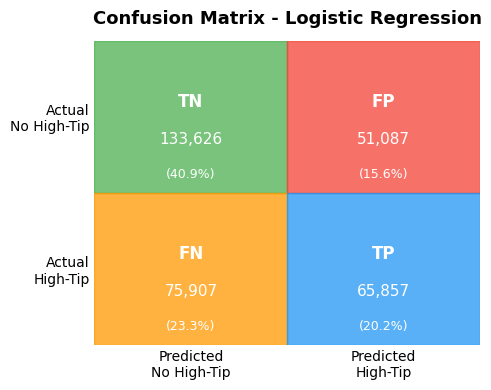

In [29]:
plot_confusion_matrix(lr_predictions, "Logistic Regression")

An ensemble of independent decision trees that aggregates by majority vote.
Tree-based models don't need scaled inputs since splits are based on rank order,
so the pipeline routes to `features_unscaled` directly.


In [30]:
rf = RandomForestClassifier(
    featuresCol="features_unscaled",
    labelCol="label",
    numTrees=30,
    maxDepth=8,
    seed=42,
)

rf_pipeline = Pipeline(stages=[*indexers, encoder, assembler, rf])

rf_model = rf_pipeline.fit(train_data)

26/06/02 19:45:01 WARN MemoryStore: Not enough space to cache rdd_575_6 in memory! (computed 72.1 MiB so far)
26/06/02 19:45:01 WARN BlockManager: Persisting block rdd_575_6 to disk instead.
26/06/02 19:45:02 WARN MemoryStore: Not enough space to cache rdd_575_2 in memory! (computed 108.7 MiB so far)
26/06/02 19:45:02 WARN BlockManager: Persisting block rdd_575_2 to disk instead.
26/06/02 19:45:02 WARN MemoryStore: Not enough space to cache rdd_575_10 in memory! (computed 257.7 MiB so far)
26/06/02 19:45:02 WARN BlockManager: Persisting block rdd_575_10 to disk instead.
26/06/02 19:45:04 WARN MemoryStore: Not enough space to cache rdd_575_10 in memory! (computed 257.7 MiB so far)
26/06/02 19:45:07 WARN MemoryStore: Not enough space to cache rdd_575_6 in memory! (computed 31.9 MiB so far)
26/06/02 19:45:07 WARN MemoryStore: Not enough space to cache rdd_575_2 in memory! (computed 386.6 MiB so far)
26/06/02 19:45:09 WARN MemoryStore: Not enough space to cache rdd_575_2 in memory! (comput

In [31]:
rf_predictions = rf_model.transform(val_data)

rf_predictions.select("label", "prediction", "probability").show(
    10, truncate=False
)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1.0  |1.0       |[0.495694748018886,0.504305251981114]   |
|1.0  |0.0       |[0.514437927532167,0.485562072467833]   |
|1.0  |0.0       |[0.5251031675105388,0.4748968324894613] |
|0.0  |0.0       |[0.5181633936857787,0.48183660631422137]|
|0.0  |0.0       |[0.5391451109407538,0.4608548890592461] |
|0.0  |0.0       |[0.5391451109407538,0.4608548890592461] |
|1.0  |0.0       |[0.5080200006729368,0.49197999932706316]|
|1.0  |0.0       |[0.5181633936857787,0.48183660631422137]|
|1.0  |0.0       |[0.5259787185797593,0.4740212814202407] |
|1.0  |0.0       |[0.503387688580779,0.496612311419221]   |
+-----+----------+----------------------------------------+
only showing top 10 rows


In [32]:
rf_auc = binary_evaluator.evaluate(rf_predictions)
rf_accuracy = accuracy_evaluator.evaluate(rf_predictions)
rf_f1 = f1_evaluator.evaluate(rf_predictions)

print("Random Forest Results")
print("AUC:", rf_auc)
print("Accuracy:", rf_accuracy)
print("F1-score:", rf_f1)

Random Forest Results
AUC: 0.6702748855588511
Accuracy: 0.6220040002817963
F1-score: 0.6081314709195758


#### Confusion Matrix


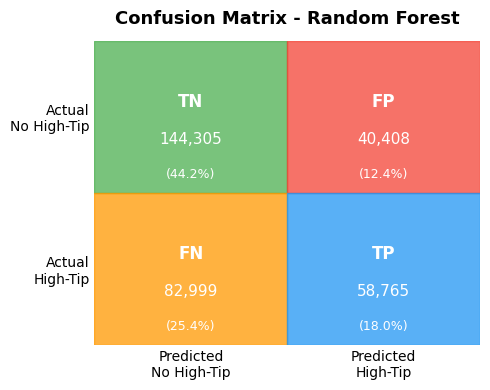

In [33]:
plot_confusion_matrix(rf_predictions, "Random Forest")

### 7.3 Gradient-Boosted Trees (GBT)

GBT builds trees sequentially, each correcting the errors of the previous.
`maxDepth=5` is shallower than the Random Forest, as the whole point of boosting
is that many weak learners combine into a strong model, so individual trees
don't need to be deep.


In [34]:
gbt = GBTClassifier(
    featuresCol="features_unscaled",
    labelCol="label",
    maxIter=20,
    maxDepth=5,
    seed=42,
)

gbt_pipeline = Pipeline(stages=[*indexers, encoder, assembler, gbt])

gbt_model = gbt_pipeline.fit(train_data)

26/06/02 19:45:38 WARN MemoryStore: Not enough space to cache rdd_790_2 in memory! (computed 67.2 MiB so far)
26/06/02 19:45:38 WARN BlockManager: Persisting block rdd_790_2 to disk instead.
26/06/02 19:45:38 WARN MemoryStore: Not enough space to cache rdd_790_6 in memory! (computed 101.3 MiB so far)
26/06/02 19:45:38 WARN BlockManager: Persisting block rdd_790_6 to disk instead.
26/06/02 19:45:39 WARN MemoryStore: Not enough space to cache rdd_790_10 in memory! (computed 240.2 MiB so far)
26/06/02 19:45:39 WARN BlockManager: Persisting block rdd_790_10 to disk instead.
26/06/02 19:45:40 WARN MemoryStore: Not enough space to cache rdd_790_10 in memory! (computed 240.2 MiB so far)
26/06/02 19:45:40 WARN MemoryStore: Not enough space to cache rdd_790_10 in memory! (computed 67.2 MiB so far)
26/06/02 19:45:43 WARN MemoryStore: Not enough space to cache rdd_790_6 in memory! (computed 67.2 MiB so far)
26/06/02 19:45:43 WARN MemoryStore: Not enough space to cache rdd_790_6 in memory! (comput

In [35]:
gbt_predictions = gbt_model.transform(val_data)

gbt_predictions.select("label", "prediction", "probability").show(
    10, truncate=False
)

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|1.0  |1.0       |[0.36272675668408677,0.6372732433159132]|
|1.0  |1.0       |[0.4629695338449559,0.537030466155044]  |
|1.0  |1.0       |[0.42911384199035907,0.5708861580096409]|
|0.0  |1.0       |[0.4678272395656874,0.5321727604343126] |
|0.0  |0.0       |[0.65455796379889,0.34544203620111]     |
|0.0  |0.0       |[0.65455796379889,0.34544203620111]     |
|1.0  |1.0       |[0.39716310821324474,0.6028368917867553]|
|1.0  |1.0       |[0.40820713356991123,0.5917928664300888]|
|1.0  |1.0       |[0.3528797851184249,0.6471202148815751] |
|1.0  |1.0       |[0.446509605327103,0.5534903946728971]  |
+-----+----------+----------------------------------------+
only showing top 10 rows


In [36]:
gbt_auc = binary_evaluator.evaluate(gbt_predictions)
gbt_accuracy = accuracy_evaluator.evaluate(gbt_predictions)
gbt_f1 = f1_evaluator.evaluate(gbt_predictions)

print("Gradient-Boosted Trees Results")
print("AUC:", gbt_auc)
print("Accuracy:", gbt_accuracy)
print("F1-score:", gbt_f1)

Gradient-Boosted Trees Results
AUC: 0.743247491649066
Accuracy: 0.6769358944121638
F1-score: 0.6751882162814532


#### Confusion Matrix


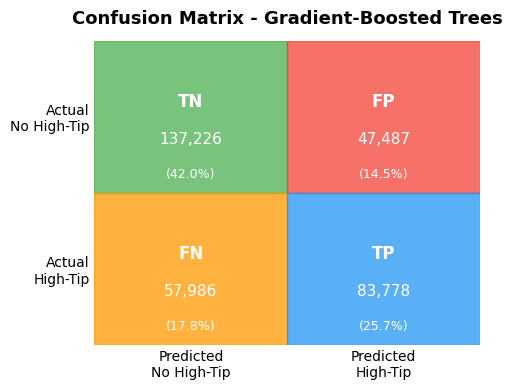

In [37]:
plot_confusion_matrix(gbt_predictions, "Gradient-Boosted Trees")

### 7.4 Regression (Predicting `tip_percentage`)

Alongside the classifiers we also model `tip_percentage` directly as a
continuous value.

Target: `tip_percentage = tip_amount / (total_amount - tip_amount)`


In [38]:
reg_data = trips_ml.select(
    "VendorID",
    "passenger_count",
    "trip_distance",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
    "fare_amount",
    "extra",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
    "trip_duration_minutes",
    "pickup_hour",
    "pickup_dayofweek",
    col("tip_percentage").alias("label"),
).filter(col("label").isNotNull() & (col("label") <= 2.0))

reg_train, reg_temp = reg_data.randomSplit([0.70, 0.30], seed=42)
reg_val, reg_test = reg_temp.randomSplit([0.50, 0.50], seed=42)

reg_train = reg_train.cache()
reg_val = reg_val.cache()
reg_test = reg_test.cache()

print(
    f"Reg train: {reg_train.count():,}  |  val: {reg_val.count():,}  |  test: {reg_test.count():,}"
)

Reg train: 1,522,967  |  val: 326,453  |  test: 324,675


In [39]:
reg_rmse_eval = RegressionEvaluator(
    labelCol="label", predictionCol="prediction", metricName="rmse"
)
reg_r2_eval = RegressionEvaluator(
    labelCol="label", predictionCol="prediction", metricName="r2"
)
reg_mae_eval = RegressionEvaluator(
    labelCol="label", predictionCol="prediction", metricName="mae"
)

#### 7.4.1 Linear Regression (baseline)


In [40]:
lin_reg = LinearRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.01,
    elasticNetParam=0.0,
)

lin_reg_pipeline = Pipeline(
    stages=[*indexers, encoder, assembler, scaler, lin_reg]
)
lin_reg_model = lin_reg_pipeline.fit(reg_train)

lin_reg_preds = lin_reg_model.transform(reg_val)
lin_reg_preds.select("label", "prediction").show(10, truncate=False)


+-------------------+-------------------+
|label              |prediction         |
+-------------------+-------------------+
|0.2                |0.19768257892293153|
|0.3550295857988166 |0.18477805057662133|
|0.24892703862660942|0.18240782625101729|
|0.0                |0.17452671244432433|
|0.19873817034700314|0.18732486071547844|
|0.0725552050473186 |0.1861734376217478 |
|0.25136612021857924|0.19194993588956014|
|0.32786885245901637|0.18000069944543456|
|0.2                |0.18316661430667228|
|0.2366863905325444 |0.19326750269605475|
+-------------------+-------------------+
only showing top 10 rows


In [41]:
lin_rmse = reg_rmse_eval.evaluate(lin_reg_preds)
lin_r2 = reg_r2_eval.evaluate(lin_reg_preds)
lin_mae = reg_mae_eval.evaluate(lin_reg_preds)

print(
    f"Linear Regression  |  RMSE: {lin_rmse:.4f}  |  MAE: {lin_mae:.4f}  |  R²: {lin_r2:.4f}"
)


Linear Regression  |  RMSE: 0.0736  |  MAE: 0.0490  |  R²: 0.2296


#### 7.4.2 GBT Regressor


In [42]:
gbt_reg = GBTRegressor(
    featuresCol="features_unscaled",
    labelCol="label",
    maxIter=20,
    maxDepth=5,
    seed=42,
)

gbt_reg_pipeline = Pipeline(stages=[*indexers, encoder, assembler, gbt_reg])
gbt_reg_model = gbt_reg_pipeline.fit(reg_train)

gbt_reg_preds = gbt_reg_model.transform(reg_val)
gbt_reg_preds.select("label", "prediction").show(10, truncate=False)


26/06/02 19:49:25 WARN MemoryStore: Not enough space to cache rdd_1608_2 in memory! (computed 67.2 MiB so far)
26/06/02 19:49:25 WARN BlockManager: Persisting block rdd_1608_2 to disk instead.
26/06/02 19:49:25 WARN MemoryStore: Not enough space to cache rdd_1608_6 in memory! (computed 101.3 MiB so far)
26/06/02 19:49:25 WARN BlockManager: Persisting block rdd_1608_6 to disk instead.
26/06/02 19:49:25 WARN MemoryStore: Not enough space to cache rdd_1608_10 in memory! (computed 240.2 MiB so far)
26/06/02 19:49:25 WARN BlockManager: Persisting block rdd_1608_10 to disk instead.
26/06/02 19:49:27 WARN MemoryStore: Not enough space to cache rdd_1608_10 in memory! (computed 240.2 MiB so far)
26/06/02 19:49:27 WARN MemoryStore: Not enough space to cache rdd_1608_10 in memory! (computed 67.2 MiB so far)
26/06/02 19:49:29 WARN MemoryStore: Not enough space to cache rdd_1608_2 in memory! (computed 360.4 MiB so far)
26/06/02 19:49:29 WARN MemoryStore: Not enough space to cache rdd_1608_6 in memo

+-------------------+-------------------+
|label              |prediction         |
+-------------------+-------------------+
|0.2                |0.19142298173484715|
|0.3550295857988166 |0.2194329809701526 |
|0.24892703862660942|0.19319073215231727|
|0.0                |0.1960447748321575 |
|0.19873817034700314|0.1880890539745156 |
|0.0725552050473186 |0.1880890539745156 |
|0.25136612021857924|0.2257525291614091 |
|0.32786885245901637|0.22146411051170697|
|0.2                |0.1906690211731942 |
|0.2366863905325444 |0.22410450622540928|
+-------------------+-------------------+
only showing top 10 rows


In [43]:
gbt_reg_rmse = reg_rmse_eval.evaluate(gbt_reg_preds)
gbt_reg_r2 = reg_r2_eval.evaluate(gbt_reg_preds)
gbt_reg_mae = reg_mae_eval.evaluate(gbt_reg_preds)

print(
    f"GBT Regressor      |  RMSE: {gbt_reg_rmse:.4f}  |  MAE: {gbt_reg_mae:.4f}  |  R²: {gbt_reg_r2:.4f}"
)


GBT Regressor      |  RMSE: 0.0735  |  MAE: 0.0486  |  R²: 0.2312


## 8. Final Evaluation on the Test Set

All models are evaluated on `test_data` here for the first time. These are the
numbers that represent actual generalization performance.


### 8.1 Precision and Recall


In [44]:
def evaluate_binary_model(predictions, model_name):

    tp = predictions.filter(
        (col("label") == 1) & (col("prediction") == 1)
    ).count()
    tn = predictions.filter(
        (col("label") == 0) & (col("prediction") == 0)
    ).count()
    fp = predictions.filter(
        (col("label") == 0) & (col("prediction") == 1)
    ).count()
    fn = predictions.filter(
        (col("label") == 1) & (col("prediction") == 0)
    ).count()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    print(f"{'─' * 35}")
    print(f"  {model_name}")
    print(f"{'─' * 35}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"{'─' * 35}\n")


### 8.2 Test Set Results (Classifiers)


In [45]:
lr_test_preds = lr_model.transform(test_data)
rf_test_preds = rf_model.transform(test_data)
gbt_test_preds = gbt_model.transform(test_data)

evaluate_binary_model(lr_test_preds, "Logistic Regression")
evaluate_binary_model(rf_test_preds, "Random Forest")
evaluate_binary_model(gbt_test_preds, "Gradient-Boosted Trees")

───────────────────────────────────
  Logistic Regression
───────────────────────────────────
  Precision : 0.5589
  Recall    : 0.4644
───────────────────────────────────

───────────────────────────────────
  Random Forest
───────────────────────────────────
  Precision : 0.5914
  Recall    : 0.4165
───────────────────────────────────

───────────────────────────────────
  Gradient-Boosted Trees
───────────────────────────────────
  Precision : 0.6377
  Recall    : 0.5915
───────────────────────────────────



### 8.3 Side-by-side Comparison


In [46]:
clf_summary = pd.DataFrame(
    {
        "Model": [
            "Logistic Regression",
            "Random Forest",
            "Gradient-Boosted Trees",
        ],
        "AUC": [
            binary_evaluator.evaluate(lr_test_preds),
            binary_evaluator.evaluate(rf_test_preds),
            binary_evaluator.evaluate(gbt_test_preds),
        ],
        "Accuracy": [
            accuracy_evaluator.evaluate(lr_test_preds),
            accuracy_evaluator.evaluate(rf_test_preds),
            accuracy_evaluator.evaluate(gbt_test_preds),
        ],
        "F1": [
            f1_evaluator.evaluate(lr_test_preds),
            f1_evaluator.evaluate(rf_test_preds),
            f1_evaluator.evaluate(gbt_test_preds),
        ],
    }
)
clf_summary = clf_summary.sort_values("AUC", ascending=False).reset_index(
    drop=True
)
clf_summary[["AUC", "Accuracy", "F1"]] = clf_summary[
    ["AUC", "Accuracy", "F1"]
].map(lambda x: f"{x:.4f}")
print("=== Classification Models (test set) ===")
print(clf_summary.to_string(index=False))

=== Classification Models (test set) ===
                 Model    AUC Accuracy     F1
Gradient-Boosted Trees 0.7436   0.6768 0.6751
         Random Forest 0.6692   0.6218 0.6083
   Logistic Regression 0.6510   0.6085 0.6023


### 8.4 Test Set Results (Regression)


In [47]:
lin_reg_test_preds = lin_reg_model.transform(reg_test)
gbt_reg_test_preds = gbt_reg_model.transform(reg_test)

reg_summary = pd.DataFrame(
    {
        "Model": ["Linear Regression", "GBT Regressor"],
        "RMSE": [
            reg_rmse_eval.evaluate(lin_reg_test_preds),
            reg_rmse_eval.evaluate(gbt_reg_test_preds),
        ],
        "MAE": [
            reg_mae_eval.evaluate(lin_reg_test_preds),
            reg_mae_eval.evaluate(gbt_reg_test_preds),
        ],
        "R²": [
            reg_r2_eval.evaluate(lin_reg_test_preds),
            reg_r2_eval.evaluate(gbt_reg_test_preds),
        ],
    }
)
reg_summary = reg_summary.sort_values("R²", ascending=False).reset_index(
    drop=True
)
reg_summary[["RMSE", "MAE", "R²"]] = reg_summary[
    ["RMSE", "MAE", "R²"]
].map(lambda x: f"{x:.4f}")
print("Regression Models: tip_percentage (test set)")
print(reg_summary.to_string(index=False))

Regression Models: tip_percentage (test set)
            Model   RMSE    MAE     R²
    GBT Regressor 0.0727 0.0485 0.2334
Linear Regression 0.0728 0.0489 0.2311
